In [47]:
import kagglehub
import pandas as pd
import os
# import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dowhy import CausalModel
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [48]:
path = kagglehub.dataset_download("mirichoi0218/insurance")
print("Path to dataset files:", path)
files = os.listdir(path)
print("Files found in directory:", files)

Path to dataset files: /Users/johannzaroli/.cache/kagglehub/datasets/mirichoi0218/insurance/versions/1
Files found in directory: ['insurance.csv']


## Overview

Dataset: https://www.kaggle.com/mirichoi0218/insurance

age: age of primary beneficiary  
sex: insurance contractor gender, female, male  
bmi: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height, objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9  
children: Number of children covered by health insurance / Number of dependents  
smoker: Smoking  
region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.  
charges: Individual medical costs billed by health insurance  

## EDA

In [49]:
df = pd.read_csv(os.path.join(path, "insurance.csv"))
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [50]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [51]:
# rows & columns
print("Number of rows:", len(df))
print("Number of columns:", 7)

Number of rows: 1338
Number of columns: 7


In [52]:
# data types
print("Numerical columns: age, bmi, children and charges")
print("Categorical columns: sex, smoker, region")
print("The categorical columns are nominal")

Numerical columns: age, bmi, children and charges
Categorical columns: sex, smoker, region
The categorical columns are nominal


In [53]:
# clean df, remove NaN values
df_cleaned = df.dropna()
len(df_cleaned)

In [54]:
# encode categorical columns
encoded_df = pd.get_dummies(df_cleaned, columns=['sex', 'smoker', 'region'], dtype=int)
encoded_df.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


### Correlation and Causal Analysis:

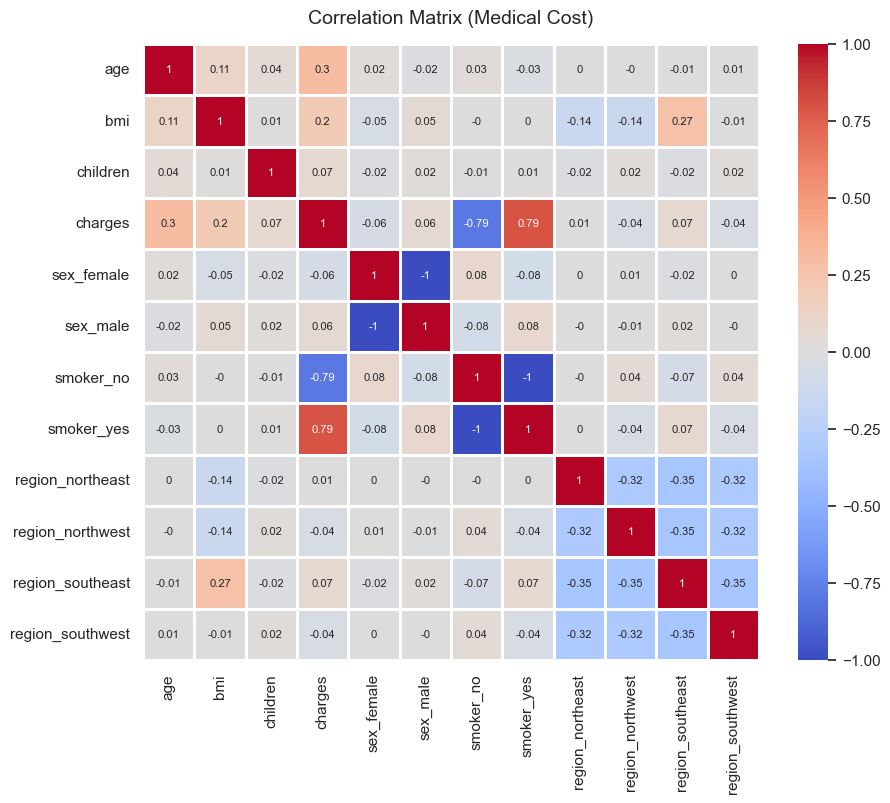

In [55]:
corr_matrix = encoded_df.corr()

# set up
sns.set_theme()
plt.figure(figsize=(10, 8))

# configure
sns.heatmap(
    corr_matrix.round(2), 
    annot=True, 
    cmap='coolwarm',
    # fmt='.2f',
    vmin=-1,
    vmax=1,
    annot_kws={"size": 8},
    square = True,
    linewidths=0.8
)

# display
plt.title("Correlation Matrix (Medical Cost)", fontsize=14, pad=15)
plt.show()

#### Observations:

There is a large correlation between being or not being a smoker and the total medical charges a patient accrues.
Age and BMI also have an impact on the total charges and are prime features for building the models.  
  
Interestingly, regions like the northeast, northwest and southwest are correlated to BMI.  
This signals that including regions into the model could cause some multicollinearity.  
  
To understand which causes the other (bmi -> region, region -> bmi) we can use doWhy, causal analysis.  
We can then use VIF (variance inflation factor) to stabalize the feature space and decide which to use for predictive power (bmi vs region) to avoid collineearity.

#### doWhy Causal Analysis:

In [56]:
"""
https://www.pywhy.org/dowhy/v0.14/
"""

# feature space
CLASSES = ["age", "bmi", "children", "sex", "smoker", "region", "charges"]

# define causal graph
causal_graph = """
digraph {
    age -> bmi; age -> charges;
    sex -> bmi; sex -> charges;
    region -> bmi;
    region -> charges
    bmi -> charges;
    smoker -> charges;
    smoker -> bmi;
}
"""

# model the causal mechanism (run on un-encoded, yet cleaned df)
model = CausalModel(
    data=df_cleaned,
    treatment="bmi",
    outcome="charges",
    graph=causal_graph
)

# identify the causal effect
print("---- Identify The Causal Effect ----")
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print("Identified estimand:", identified_estimand)

# estimate the causal effect using a linear regression method
print("\n")
print("---- Estimate The Causal Effect ----")
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)
print("Causal effect estimate:", estimate.value)

# refute the estimate
print("\n")
print("---- Refute the estimate ----")
refutation = model.refute_estimate(
    identified_estimand, 
    estimate, 
    method_name="random_common_cause"
)
print("Refutation results:", refutation)

---- Identify The Causal Effect ----
Identified estimand: Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                                     
──────(E[charges|smoker,age,sex,region])
d[bmi]                                  
Estimand assumption 1, Unconfoundedness: If U→{bmi} and U→charges then P(charges|bmi,smoker,age,sex,region,U) = P(charges|bmi,smoker,age,sex,region)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
  d                                     
──────(E[charges|smoker,age,sex,region])
d[bmi]                                  
Estimand assumption 1, Unconfoundedness: If U→{bmi} and U→charges then P(charges|bmi,smoker,age,sex,region,U) = P(charges|bmi,smoker,age,sex,region)



---- Estimate The Causal Effect ----
Causal effect estimate: 340.4591811730829



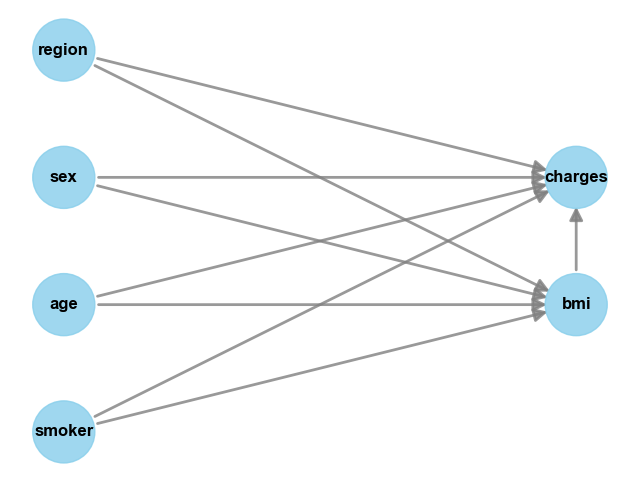

In [57]:
# view graph and export
model.view_model(file_name=os.path.join("graphs", "causal_graph"))

#### Observations:
Age, sex, smoker and region are backdoors/confounders and they impact both BMI and charges.  
The causal effect estimate shows that a 1 unit increase in bmi, causes an increases in charges by $340.  
A high p-value of 0.96, shows that the model is robust.  

#### Variance Inflation Factor:

In [60]:
"""
https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html
"""

# copy feature space, omitting charges and redundant features
X = encoded_df[["age", "bmi", "children", "sex_female", "smoker_yes", 
    "region_northeast", "region_northwest", "region_southeast"]].copy()

# add column for calculation
X = add_constant(X)

# compute VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

            feature       VIF
8  region_southeast  1.597103
6  region_northeast  1.526210
7  region_northwest  1.524748
2               bmi  1.106630
1               age  1.016822
5        smoker_yes  1.012074
4        sex_female  1.008900
3          children  1.004011
0             const  1.000000


#### Observations:
The Variance Inflation Factor results show that none of the features have a high multicollinearity (VIF score > 5), therefore none should be dropped. The regions have slightly higher VIF scores than their peers. 

We know from the doWhy analysis that the regions are cofounders for both bmi and charges. Arguably, there are lifestyle differences in each region that are impacting bmi and also cost of living differences in each region that are impacting charge amounts; among others.  
    
In conclusion, the regions likely carry some predictive power; in spite of their limied correlation to charges. Therefore, a parameter sweep that experiments with including or excluding the regions will determine their impact on the model performance.   
  
(Ignore the const row)